# 12. Adjusted Community Structure Plots (Python)

Minimal plotting notebook for README-linked outputs:
- `fig_12_02_pairwise_similarity_mixed`
- `fig_12_03_pairwise_adjusted_margins`


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import SVG, display

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import workflow_core as wc

context, base_data, base, advanced = wc.bootstrap_notebook()

## Load Inputs


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42

pairwise_effects_body = pd.read_csv(
    wc.table_path(context, 30, "pairwise_similarity_mixed_effects"), sep="\t"
)
adjusted_margins_body = pd.read_csv(
    wc.table_path(context, 38, "pairwise_adjusted_margins"), sep="\t"
)

## Plot Helpers


In [3]:
def save_svg_and_jpg(fig: plt.Figure, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    fig.savefig(output_path.with_suffix(".jpg"), bbox_inches="tight", dpi=300)


def plot_pairwise_effects(table_df: pd.DataFrame, output_path: Path) -> None:
    plot_df = table_df.copy().sort_values("estimate")
    plot_df["significant"] = plot_df["qvalue"].fillna(1.0) <= 0.1
    plot_df["fit_quality"] = np.where(
        plot_df.get("status", "ok") == "ok_singular",
        "Singular fit",
        "Regular fit",
    )
    color_map = {True: "#b22222", False: "#3b6a8f"}
    marker_map = {"Regular fit": "o", "Singular fit": "^"}

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axvline(0, color="#808080", linestyle="--", linewidth=0.9)

    y_values = np.arange(len(plot_df))
    for idx, row in plot_df.reset_index(drop=True).iterrows():
        row_color = color_map[bool(row["significant"])]
        ax.hlines(
            y=idx,
            xmin=row["conf.low"],
            xmax=row["conf.high"],
            color=row_color,
            linewidth=2,
        )
        ax.scatter(
            row["estimate"],
            idx,
            color=row_color,
            marker=marker_map[row["fit_quality"]],
            s=80,
            edgecolor="black",
            linewidth=0.5,
            zorder=3,
        )
        ax.text(
            row["conf.high"] + 0.01,
            idx,
            f"q={row['qvalue']:.3g}" if pd.notna(row["qvalue"]) else "q=NA",
            va="center",
            fontsize=9,
        )

    ax.set_yticks(y_values)
    ax.set_yticklabels(plot_df["term_label"])
    ax.set_xlabel("Estimate (lower Bray-Curtis = higher similarity)")
    ax.set_ylabel("")
    ax.set_title("Adjusted pairwise mixed-effects model (body region)")
    fig.tight_layout()
    save_svg_and_jpg(fig, output_path)
    plt.close(fig)


def plot_adjusted_margins(
    margins: pd.DataFrame,
    output_path: Path,
    panel_size: tuple[float, float] = (3.6, 5.0),
) -> None:
    terms = margins["term_label"].drop_duplicates().tolist()
    n_terms = len(terms)
    fig, axes = plt.subplots(
        1,
        n_terms,
        figsize=(panel_size[0] * n_terms, panel_size[1]),
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()
    level_colors = {"Not shared": "#8d99ae", "Shared": "#2a9d8f"}

    for idx, term in enumerate(terms):
        ax = axes[idx]
        sub = margins.loc[margins["term_label"] == term].copy()
        sub["level"] = pd.Categorical(
            sub["level"], categories=["Not shared", "Shared"], ordered=True
        )
        sub = sub.sort_values("level")
        x = np.arange(sub.shape[0])
        colors = [level_colors[str(level)] for level in sub["level"]]
        for x_pos, (_, row), color in zip(x, sub.iterrows(), colors):
            lower_err = row["emmean"] - row["conf.low"]
            upper_err = row["conf.high"] - row["emmean"]
            ax.errorbar(
                x_pos,
                row["emmean"],
                yerr=np.array([[lower_err], [upper_err]]),
                fmt="none",
                ecolor=color,
                capsize=5,
                linewidth=1.8,
            )
            ax.scatter(x_pos, row["emmean"], s=90, color=color, zorder=3)
        for x_pos, mean_val in zip(x, sub["emmean"]):
            ax.text(
                x_pos,
                mean_val + 0.012,
                f"{mean_val:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )
        ax.set_title(term, fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels(sub["level"], rotation=20, ha="right")
        if idx == 0:
            ax.set_ylabel("Adjusted predicted Bray-Curtis distance")
        else:
            ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_ylim(
            max(0.0, margins["conf.low"].min() - 0.03),
            min(1.0, margins["conf.high"].max() + 0.03),
        )

    fig.tight_layout()
    save_svg_and_jpg(fig, output_path)
    plt.close(fig)

## Render Figure 12 Panels


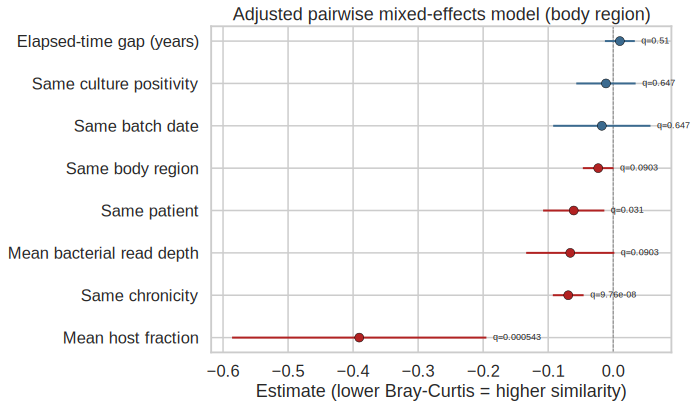

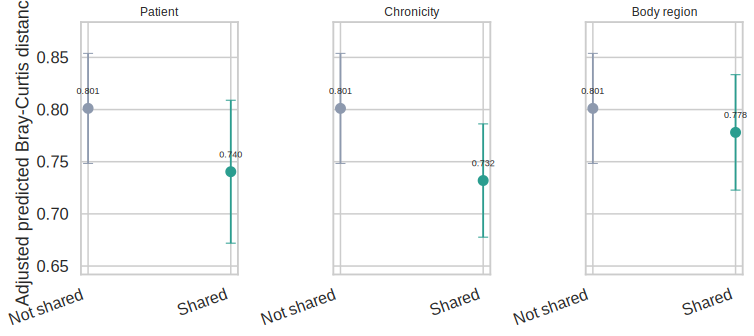

In [4]:
body_effects = pairwise_effects_body.copy()
body_effects["model"] = "body_region_model"
fig_12_02 = wc.figure_path(context, 13, "pairwise_similarity_mixed")
plot_pairwise_effects(body_effects, fig_12_02)

adjusted_margins_body["term_label"] = adjusted_margins_body["term_label"].map(
    lambda x: x.replace("Same ", "").capitalize()
)
fig_12_03 = wc.figure_path(context, 22, "pairwise_adjusted_margins")
plot_adjusted_margins(adjusted_margins_body, fig_12_03)

display(SVG(filename=str(fig_12_02)))
display(SVG(filename=str(fig_12_03)))